In [136]:
# Single Neuron Regression Analysis :)
import os

from analyses.data_loader import explode_spike_data
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [137]:
raw_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_dir_ols_on_windows.pkl')
significant_results = raw_results[raw_results['p_value'] < 0.05]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())

(1440, 11)
255


In [138]:
aff_to_69X = raw_results[(raw_results['Behavior'] == 'AffiliationTo') & (raw_results['Source_Monkey'] =='69X')]
unique_neurons = aff_to_69X['NeuronID'].unique()
print(len(unique_neurons))
for neuron in unique_neurons:
    data_for_plot = aff_to_69X[aff_to_69X['NeuronID'] == neuron]

262


In [112]:
significant_results['Behavior'].value_counts()

Behavior
SubmissionFrom     274
AgonismTo          241
SubmissionTo       238
AffiliationTo      236
AffiliationFrom    233
AgonismFrom        218
Name: count, dtype: int64

In [113]:
significant_results['Source_Monkey'].value_counts()

Source_Monkey
7124    176
69X     175
151J    163
87J     158
94B     157
110E    157
72X     152
143H    151
67G     151
Name: count, dtype: int64

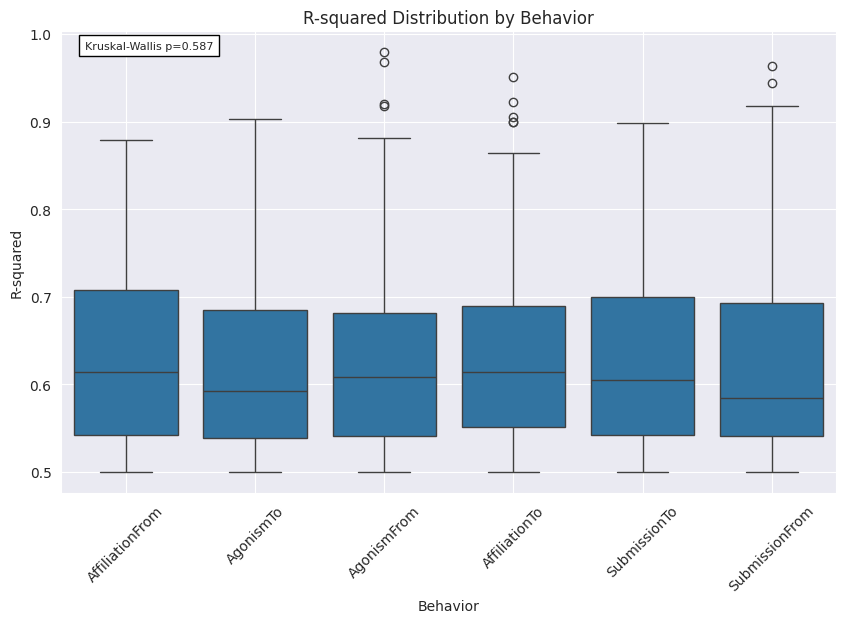

In [114]:
# Box Plot
from scipy.stats import kruskal

# 1. Kruskal-Wallis Test (behavior)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Behavior')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Behavior',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Behavior')
plt.xlabel('Behavior')
plt.ylabel('R-squared')
plt.xticks(rotation=45)
plt.grid(True)

# 3. Add text with p-value
plt.text(
    0.03, 0.98,
    f'Kruskal-Wallis p={p:.3f}',
    horizontalalignment='left',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

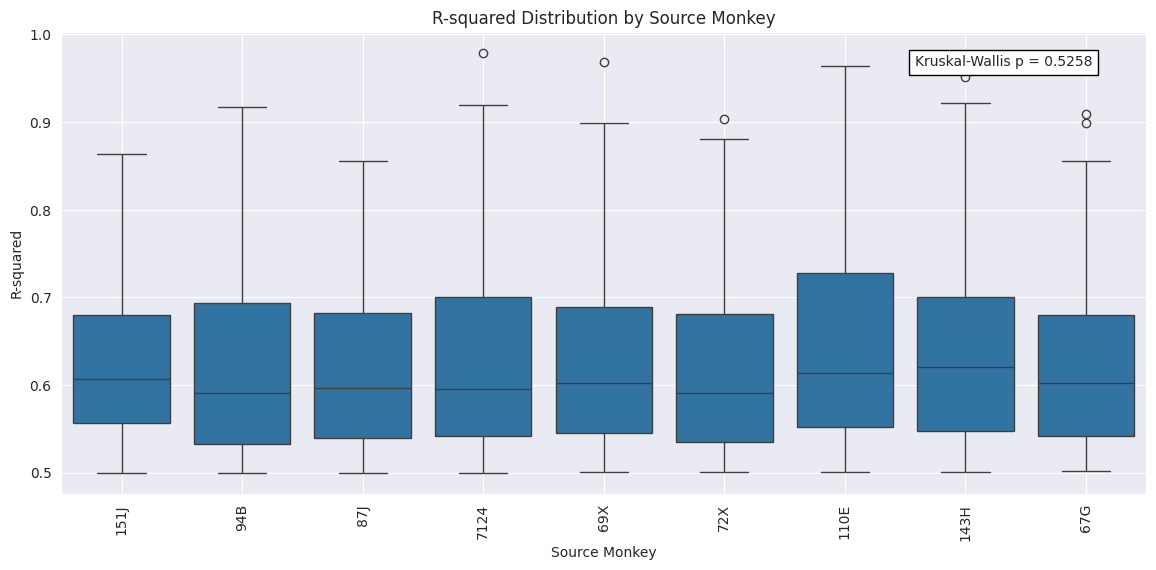

In [115]:
# 1. Kruskal-Wallis Test (Source_Monkey 기준)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Source_Monkey')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(14, 6))  # Monkey가 많으니까 width 넓힘
sns.boxplot(
    x='Source_Monkey',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Source Monkey')
plt.xlabel('Source Monkey')
plt.ylabel('R-squared')
plt.xticks(rotation=90)
plt.grid(True)

# 3. Add p-value to upper right corner
plt.text(
    0.95, 0.95,
    f'Kruskal-Wallis p = {p:.4f}',
    horizontalalignment='right',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

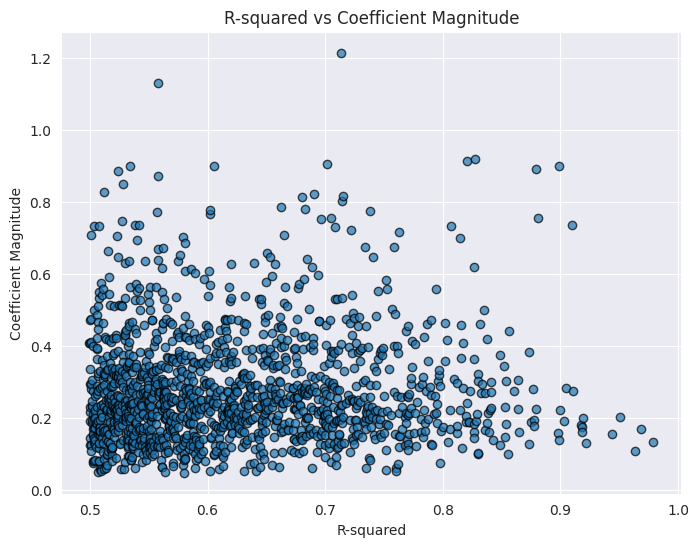

In [116]:
plt.figure(figsize=(8,6))
plt.scatter(
    significant_results['R-squared'],
    np.abs(significant_results['coef']) ,  # Coef magnitude (절댓값)
    alpha=0.7,
    edgecolors='k'
)
plt.title('R-squared vs Coefficient Magnitude')
plt.xlabel('R-squared')
plt.ylabel('Coefficient Magnitude')
plt.grid(True)
plt.show()

In [119]:
filtered_results = raw_results[(raw_results['p_value'] < 0.05) & (raw_results['R-squared'] > 0.5)]
summed_r2 = filtered_results.groupby('Source_Monkey')['R-squared'].sum().reset_index()
summed_r2 = summed_r2.sort_values(by='R-squared', ascending=False)

In [65]:
summed_r2

,Source_Monkey,R-squared
5,7124,109.973713
4,69X,109.435671
0,110E,101.015275
2,151J,100.241528
7,87J,97.601521
8,94B,96.727828
1,143H,96.009648
6,72X,94.053704
3,67G,93.445184


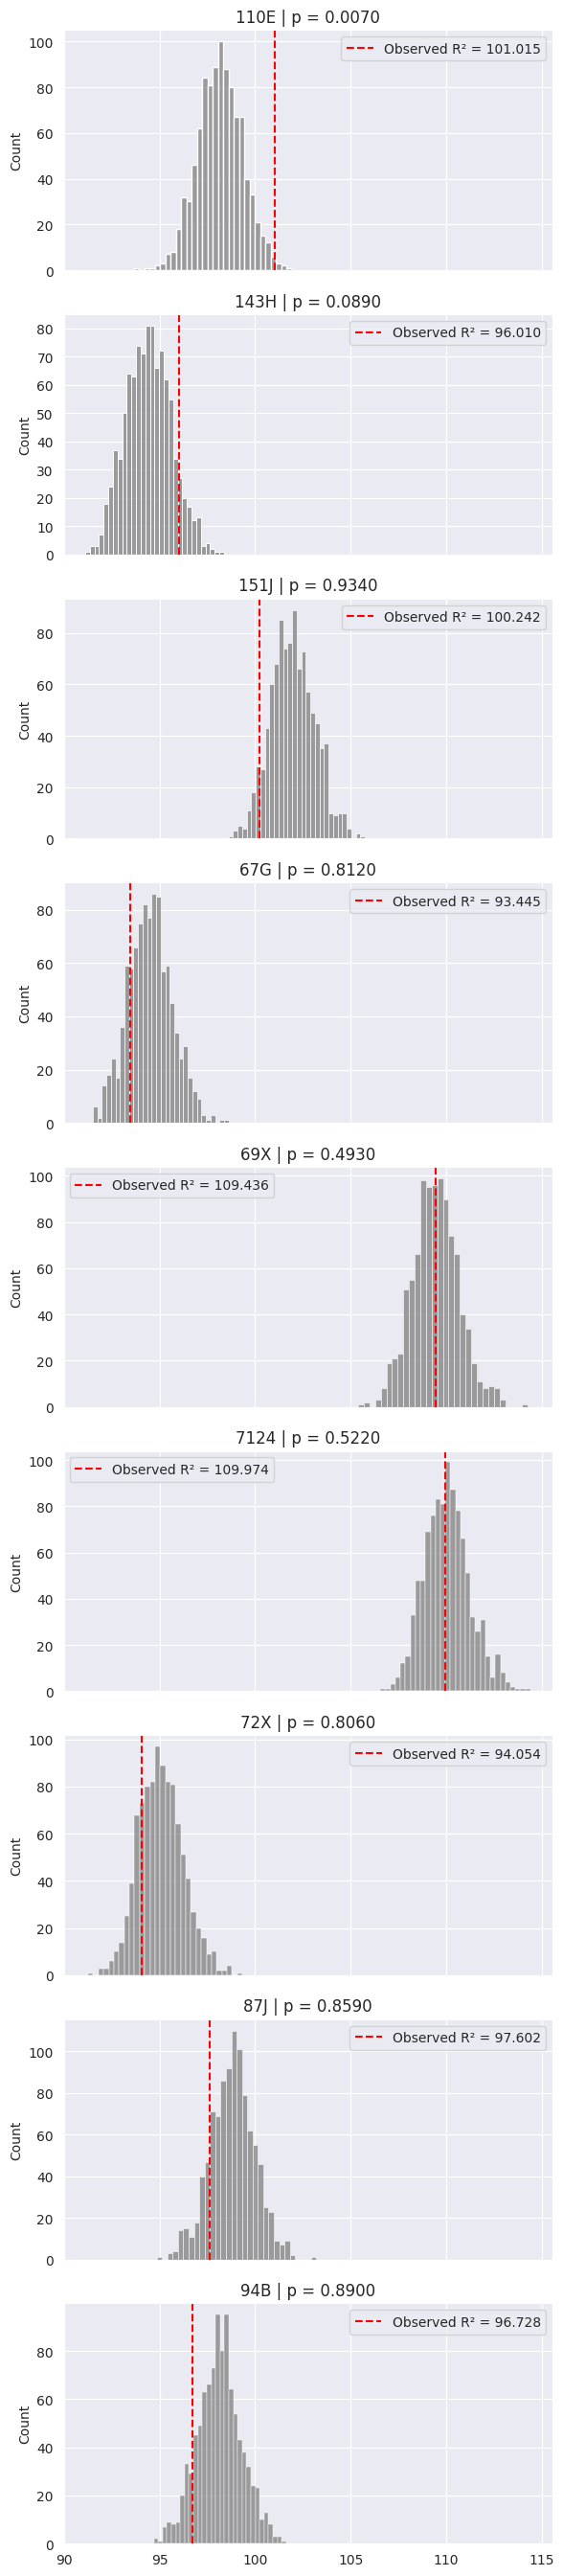

In [120]:
# Settings
n_permutations = 1000
source_col = 'Source_Monkey'
r2_col = 'R-squared'

# Step 1: Observed R² sums
observed = filtered_results.groupby(source_col)[r2_col].sum()

# Step 2: Permutations
perm_sums = {monkey: [] for monkey in observed.index}

for _ in range(n_permutations):
    shuffled = significant_results.copy()
    shuffled[source_col] = np.random.permutation(shuffled[source_col].values)
    permuted_sum = shuffled.groupby(source_col)[r2_col].sum()

    for monkey in observed.index:
        perm_sums[monkey].append(permuted_sum.get(monkey, 0))

# Step 3: Compute p-values
p_values = {}
for monkey in observed.index:
    perm_array = np.array(perm_sums[monkey])
    obs = observed[monkey]
    p = np.mean(perm_array >= obs)
    p_values[monkey] = p

# Step 4: Plot
fig, axs = plt.subplots(len(observed), 1, figsize=(6, 3 * len(observed)), sharex=True)

for i, monkey in enumerate(observed.index):
    ax = axs[i]
    sns.histplot(perm_sums[monkey], bins=30, kde=False, ax=ax, color='gray')
    ax.axvline(observed[monkey], color='red', linestyle='--', label=f"Observed R² = {observed[monkey]:.3f}")
    ax.set_title(f"{monkey} | p = {p_values[monkey]:.4f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [139]:
# Step 1: 먼저 전체 significant result를 behavior × source_monkey 조합으로 정리
filtered_df = significant_results.sort_values('R-squared', ascending=False)
# Step 2: pivot (NeuronID × [Behavior|SourceMonkey] 조합 → column 이름을 합쳐서 사용)
filtered_df['Behavior_Source'] = filtered_df['Behavior'] + '__' + filtered_df['Source_Monkey']


In [140]:
filtered_df = (
    filtered_df.sort_values('R-squared', ascending=False)
    .drop_duplicates(subset=['NeuronID', 'Behavior_Source'])
) # only pick ones with highest R-squared values
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior_Source', values='R-squared').fillna(0)

In [141]:
pivot_df

Behavior_Source,AffiliationFrom__110E,AffiliationFrom__143H,AffiliationFrom__151J,AffiliationFrom__67G,AffiliationFrom__69X,AffiliationFrom__7124,AffiliationFrom__72X,AffiliationFrom__87J,AffiliationFrom__94B,AffiliationTo__110E,...,SubmissionFrom__94B,SubmissionTo__110E,SubmissionTo__143H,SubmissionTo__151J,SubmissionTo__67G,SubmissionTo__69X,SubmissionTo__7124,SubmissionTo__72X,SubmissionTo__87J,SubmissionTo__94B
NeuronID,,,,,,,,,,,,,,,,,,,,,
AMG_2023-09-26_1_Channel.C_014_Unit 1,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.644902,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AMG_2023-09-26_1_Channel.C_018_Unit 1,0.000000,0.000000,0.00000,0.0,0.000000,0.752882,0.000000,0.681770,0.000000,0.000000,...,0.0,0.0,0.0,0.662718,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AMG_2023-09-26_1_Channel.C_018_Unit 2,0.000000,0.000000,0.00000,0.0,0.700392,0.000000,0.639898,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.624119,0.000000,0.000000,0.000000,0.712303,0.0
AMG_2023-09-26_1_Channel.C_020_Unit 1,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.645688,0.532960,...,0.0,0.0,0.0,0.685208,0.000000,0.512801,0.000000,0.000000,0.000000,0.0
AMG_2023-09-26_1_Channel.C_027_Unit 1,0.000000,0.538654,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.568839,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unknown_2023-12-18_2_Channel.C_017_Unit 1,0.648591,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.538287,0.000000,0.720377,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.540179,0.000000,0.713262,0.0
Unknown_2023-12-18_3_Channel.C_003,0.000000,0.687118,0.52478,0.0,0.673278,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.828485,0.000000,0.668138,0.000000,0.0
Unknown_2023-12-18_3_Channel.C_015_Unit 1,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.762486,0.000000,0.0


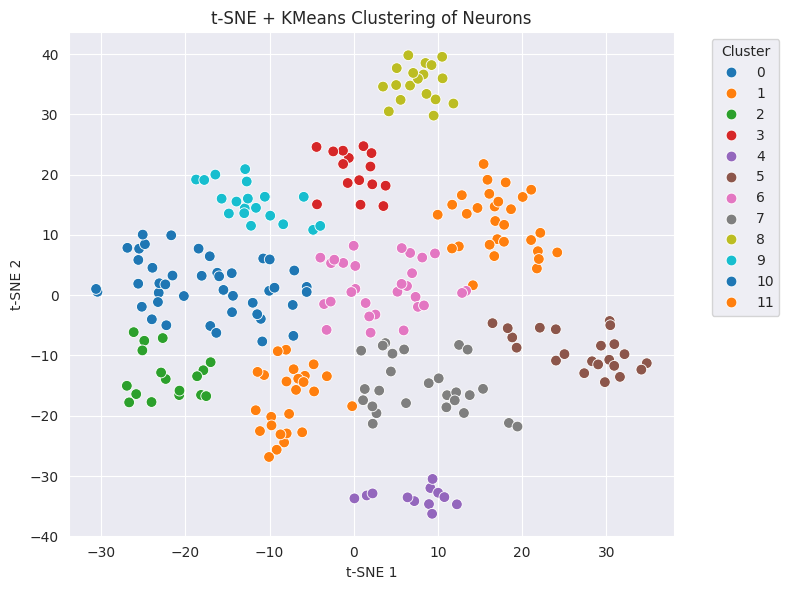

In [149]:
# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)

# t-sne
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

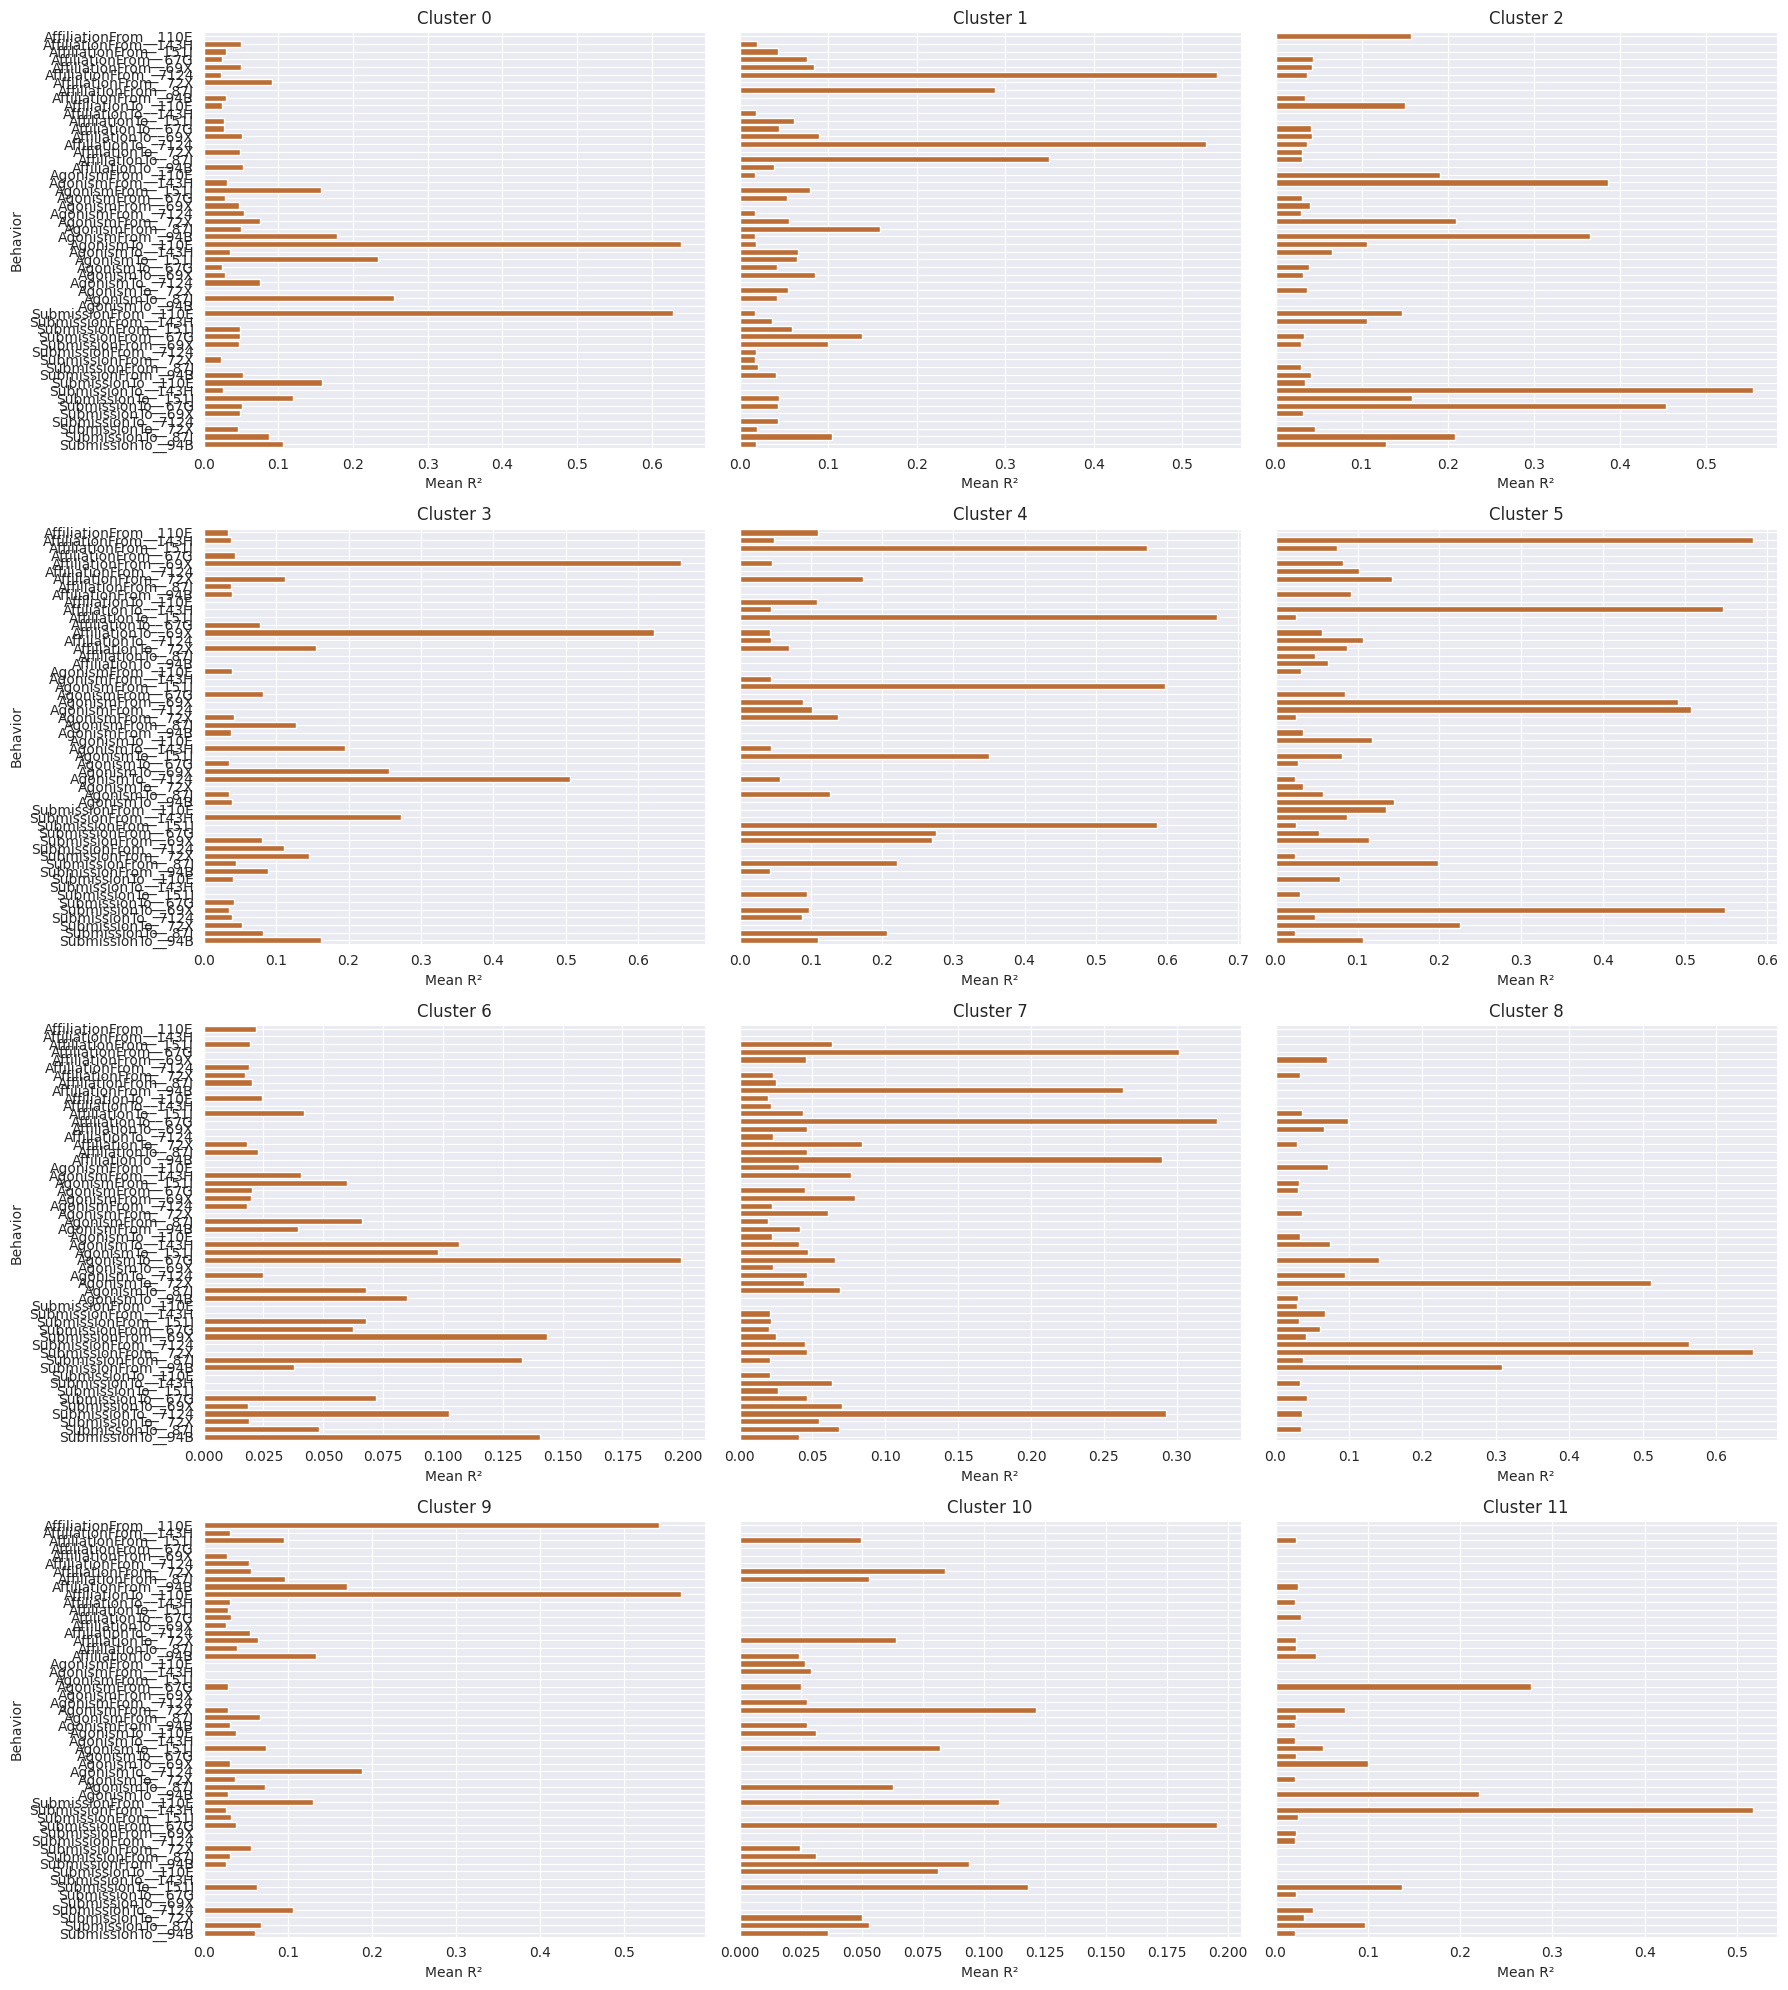

In [150]:
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels

n_clusters = pivot_df_clustered['Cluster'].nunique()

ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()

for i, cluster_id in enumerate(sorted(pivot_df_clustered['Cluster'].unique())):
    ax = axes[i]

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    # print(cluster_df)
    mean_r2 = cluster_df.mean()
    # print(mean_r2)
    mean_r2 = mean_r2.sort_index(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i % ncols == 0:
        ax.set_ylabel("Behavior")
    else:
        ax.set_ylabel("")
    ax.grid(True)

# delete remaining empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [158]:
%reset
%matplotlib inline
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_dir_ols_on_windows.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]

Nothing done.


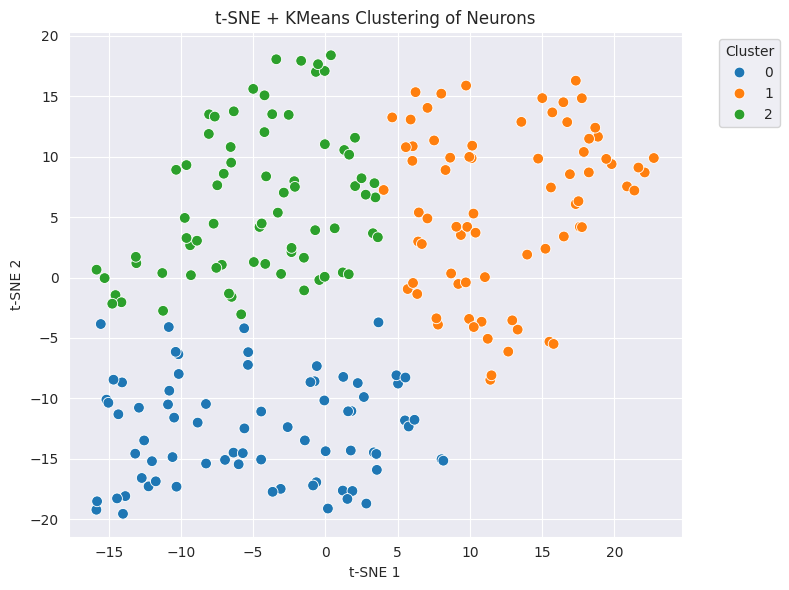

In [154]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Source_Monkey'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × SourceMonkey) wide format....
pivot_df = filtered_df.pivot(index='NeuronID', columns='Source_Monkey', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=20, n_init=5)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

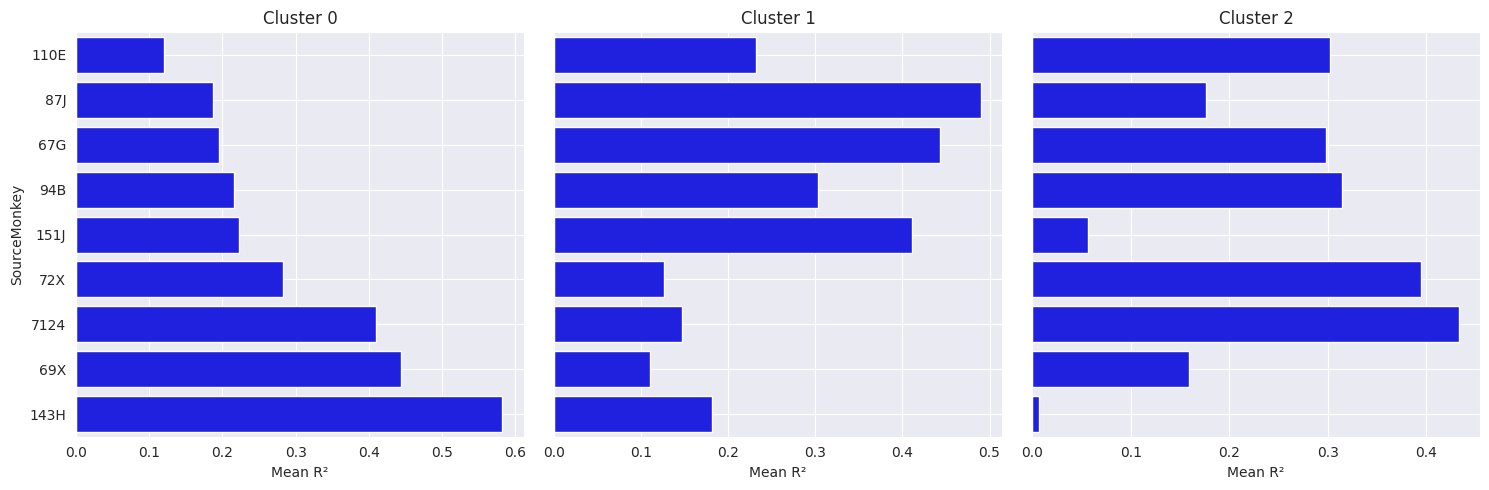

In [155]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='blue')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()

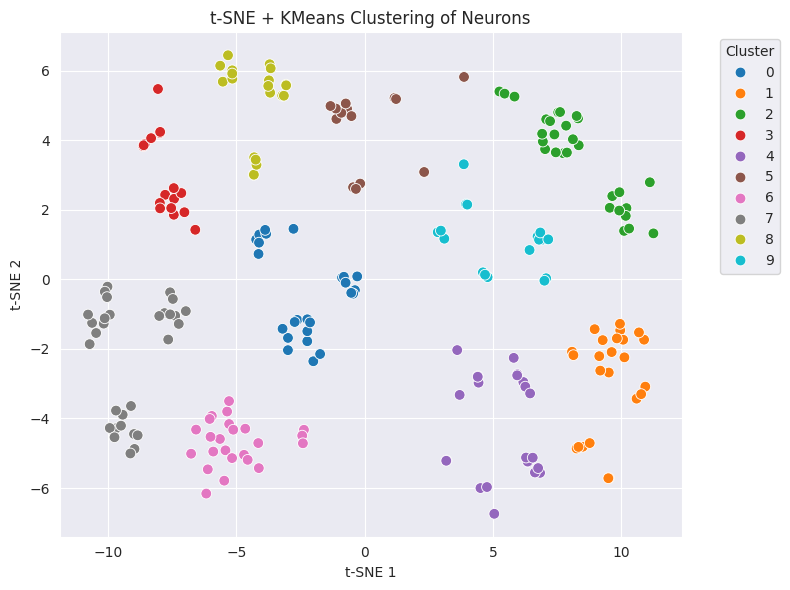

In [159]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Behavior'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × Behavior) wide format 만들기
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

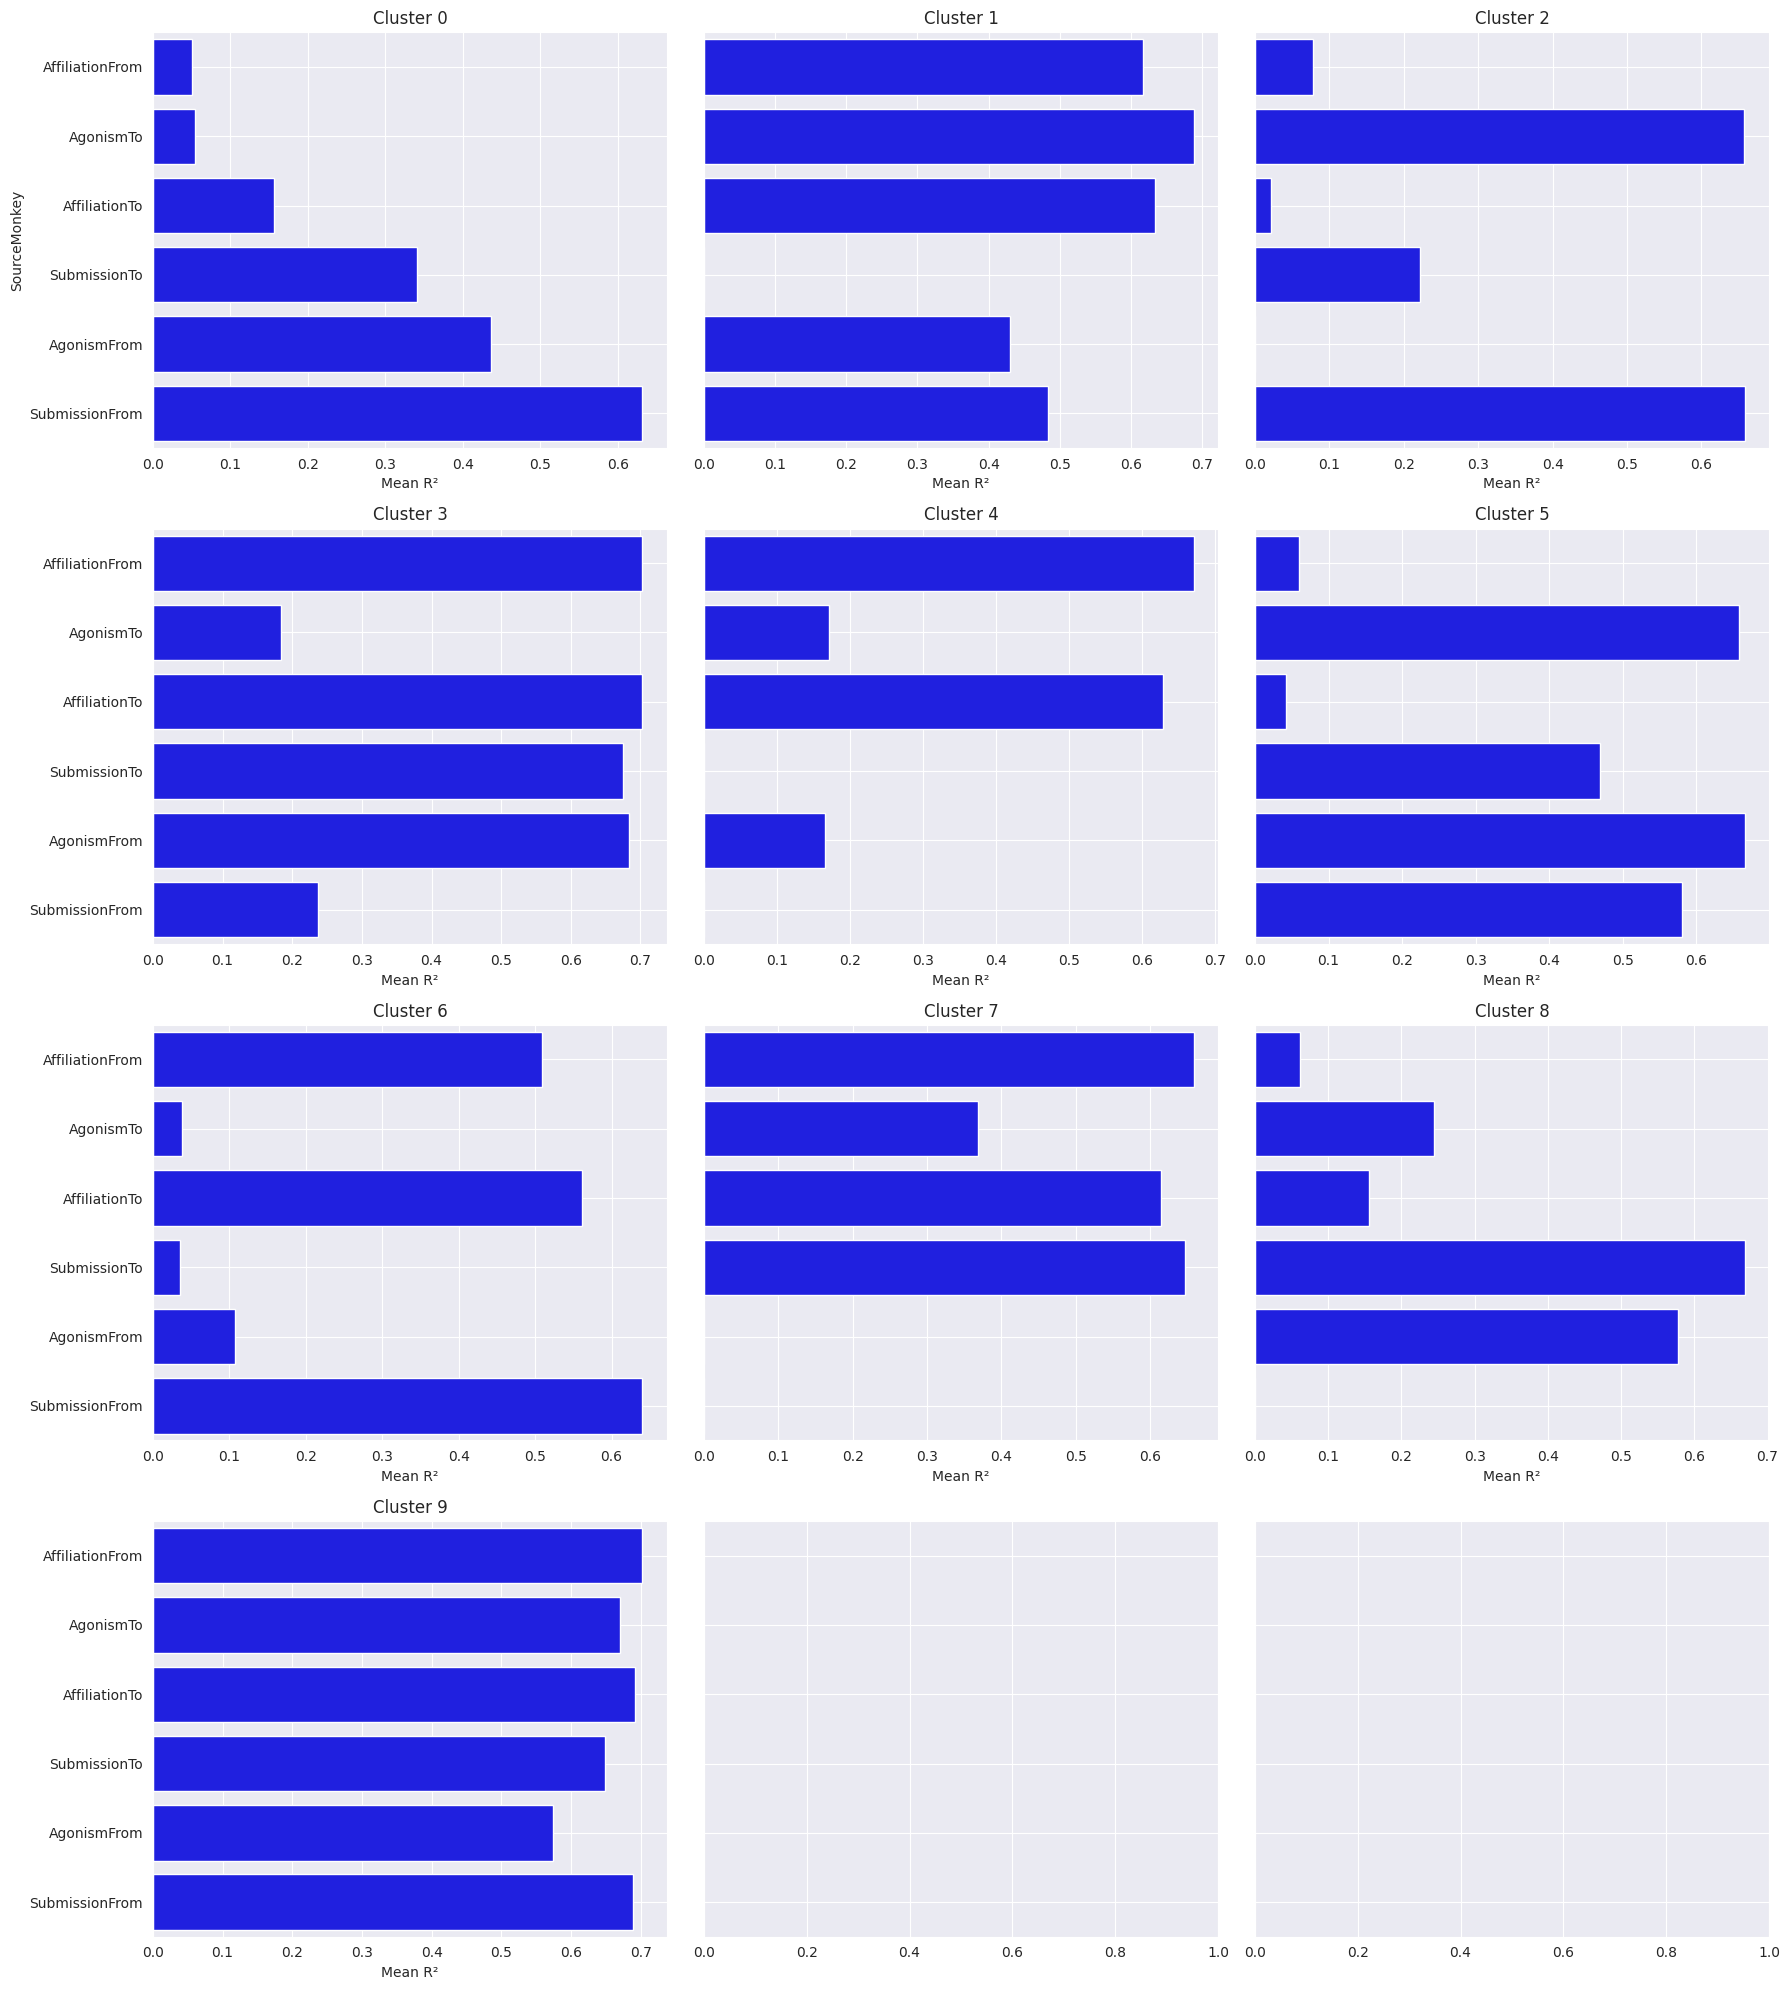

In [130]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)
axes = axes.flatten()

for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='blue')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()